In [3]:
import math
import torch
import matplotlib.pyplot as plt

In [9]:
x = torch.linspace(-3, 3, 1000)
y = torch.sin(x)

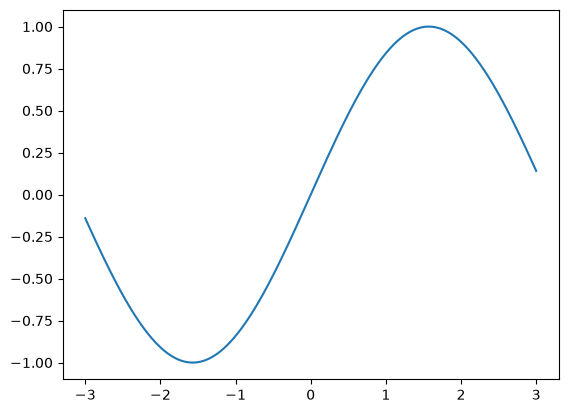

In [10]:
plt.plot(x,  y)

- 3차함수를 써서 sin 그래프 비슷하게 만들어 보기

In [21]:
a = torch.randn(1)
b = torch.randn(1)
c = torch.randn(1)
d = torch.randn(1)

y_random = a*x**3 + b*x**2 + c*x + d

In [39]:
a = torch.randn(1)
b = torch.randn(1)
c = torch.randn(1)
d = torch.randn(1)

y_random = a*x**3 + b*x**2 + c*x + d

learning_rate = 1e-6

x = torch.linspace(-3, 3, 1000)
y = torch.sin(x)

a = torch.randn(1)
b = torch.randn(1)
c = torch.randn(1)
d = torch.randn(1)


for epoch in range(3000):
    y_pred = a*x**3 + b*x**2 + c*x + d   # 예측값 찾기
    loss = (y_pred-y).pow(2).sum().item()  # 손실함수의 근거하여 손실을 계산

    # 기울기 구하기
    grad_y_pred = 2.0*(y_pred-y)      
    grad_a = (grad_y_pred*x**3).sum()
    grad_b = (grad_y_pred*x**2).sum()
    grad_c = (grad_y_pred*x).sum()
    grad_d = (grad_y_pred).sum()


    # a,b,c,d 업데이트 
    a = a - learning_rate*grad_a
    b = b - learning_rate*grad_b
    c -= learning_rate*grad_d
    d -= learning_rate*grad_a

    if epoch % 100 == 0:
        print(f"epoch: {epoch},  loss: {loss}")
        print(f"a: {a.item()},  b: {b.item()}")
        print(f"=="*10)
   
    

epoch: 0,  loss: 105603.96875
a: -0.6628161668777466,  b: -0.49327805638313293
epoch: 100,  loss: 616.2916259765625
a: 0.0706215351819992,  b: 0.034343406558036804
epoch: 200,  loss: 580.0623168945312
a: 0.06590627133846283,  b: 0.053843460977077484
epoch: 300,  loss: 554.2224731445312
a: 0.06174321100115776,  b: 0.05530644208192825
epoch: 400,  loss: 528.8775024414062
a: 0.057545147836208344,  b: 0.056105080991983414
epoch: 500,  loss: 503.9181823730469
a: 0.053289350122213364,  b: 0.05688925459980965
epoch: 600,  loss: 479.3658752441406
a: 0.0489741750061512,  b: 0.05768340080976486
epoch: 700,  loss: 455.24737548828125
a: 0.044598765671253204,  b: 0.058488618582487106
epoch: 800,  loss: 431.590576171875
a: 0.040162283927202225,  b: 0.05930507555603981
epoch: 900,  loss: 408.42431640625
a: 0.03566386550664902,  b: 0.060132935643196106
epoch: 1000,  loss: 385.77850341796875
a: 0.031102657318115234,  b: 0.06097233295440674
epoch: 1100,  loss: 363.68414306640625
a: 0.02647777646780014, 

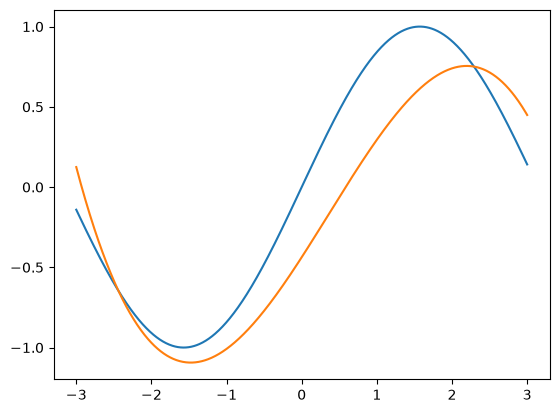

In [41]:
y_pred = a*x**3 + b*x**2 + c*x + d  
plt.plot(x,  y)
plt.plot(x,  y_pred )

## 보다 나은 방법  
- p85

In [13]:
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-3, 3, 1000)
y = torch.sin(x)


# 가중치 초기화
a = torch.tensor(torch.randn(1), requires_grad=True )  
b = torch.tensor(torch.randn(1), requires_grad=True )  
c = torch.tensor(torch.randn(1), requires_grad=True )  
d = torch.tensor(torch.randn(1), requires_grad=True )  

for epoch in range(6001):
    # 순전파
    y_pred = a*x**3 + b*x**2 + c*x + d   # 예측값 찾기

    # 오차 계산 SSE
    loss = (y_pred-y).pow(2).sum() # 손실함수의 근거하여 손실을 계산

    # backward  : 미분해서 기울기 다 찾아두기
    loss.backward()

    # a,b,c,d 업데이트    
    with torch.no_grad():        
        a -= learning_rate*a.grad
        b -= learning_rate*b.grad
        c -= learning_rate*c.grad
        d -= learning_rate*d.grad

        # 각 변수의 기울기 초기화
        a.grad = None
        b.grad = None
        c.grad = None
        d.grad = None

    if epoch % 1000 == 0:
        print(f"epoch: {epoch},  loss: {loss}")
        print(f"a: {a.item()},  b: {b.item()}")
        print(f"=="*10)   
    

/tmp/ipykernel_5091/3543498555.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  a = torch.tensor(torch.randn(1), requires_grad=True )
/tmp/ipykernel_5091/3543498555.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  b = torch.tensor(torch.randn(1), requires_grad=True )
/tmp/ipykernel_5091/3543498555.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c = torch.tensor(torch.randn(1), requires_grad=True )
/tmp/ipykernel_5091/3543498555.py:12: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().

epoch: 0,  loss: 112297.7578125
a: 0.0989617258310318,  b: -2.165409803390503
epoch: 1000,  loss: 116.38706970214844
a: -0.087134450674057,  b: 0.09468099474906921
epoch: 2000,  loss: 23.266077041625977
a: -0.0940239205956459,  b: 0.040100328624248505
epoch: 3000,  loss: 6.619452476501465
a: -0.09671611338853836,  b: 0.016983747482299805
epoch: 4000,  loss: 3.642143964767456
a: -0.09776818752288818,  b: 0.007193143013864756
epoch: 5000,  loss: 3.1094141006469727
a: -0.09817928820848465,  b: 0.0030465195886790752
epoch: 6000,  loss: 3.0140573978424072
a: -0.09833996742963791,  b: 0.0012902951566502452


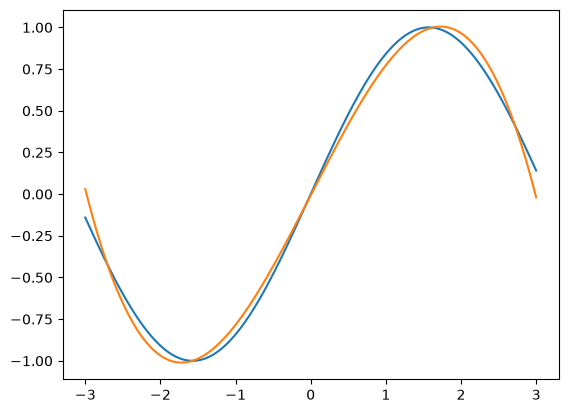

In [14]:
y_pred = a*x**3 + b*x**2 + c*x + d  
plt.plot(x,  y)
plt.plot(x,  y_pred.detach().numpy() )

## 제일 좋은 방법
- 파이토치 모듈 사용하기 1  p88

In [15]:
import torch
import torch.nn as nn

In [22]:
class Poly(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 가중치 초기화
        self.a = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(1))
        self.d = nn.Parameter(torch.randn(1))

    def forward(self, x):
        y_pred  = self.a*x**3 + self.b*x**2 + self.c*x + self.d
        return y_pred
            

In [24]:
# 하이퍼 파라미터 
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-3, 3, 1000)
y = torch.sin(x)

# 모델초기화
model = Poly()

for epoch in range(6001):    
    y_pred = model(x)   # 순전파    
    criterion = nn.MSELoss(reduction='sum')   # 손실함수 정의   
    loss = criterion(y_pred, y)            # 손실 계산    
    loss.backward()                 # backward  : 미분해서 기울기 다 찾아두기

    # a,b,c,d 업데이트    
    with torch.no_grad():        
        model.a -= learning_rate*model.a.grad
        model.b -= learning_rate*model.b.grad
        model.c -= learning_rate*model.c.grad
        model.d -= learning_rate*model.d.grad

        # 각 변수의 기울기 초기화
        model.a.grad = None
        model.b.grad = None
        model.c.grad = None
        model.d.grad = None

    if epoch % 1000 == 0:
        print(f"epoch: {epoch},  loss: {loss}")
        print(f"a: {a.item()},  b: {b.item()}")
        print(f"=="*10)   
    

epoch: 0,  loss: 243130.1875
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 1000,  loss: 74.03388977050781
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 2000,  loss: 13.884033203125
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 3000,  loss: 4.663906097412109
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 4000,  loss: 3.2497363090515137
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 5000,  loss: 3.0326671600341797
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 6000,  loss: 2.9993202686309814
a: -0.09833996742963791,  b: 0.0012902951566502452


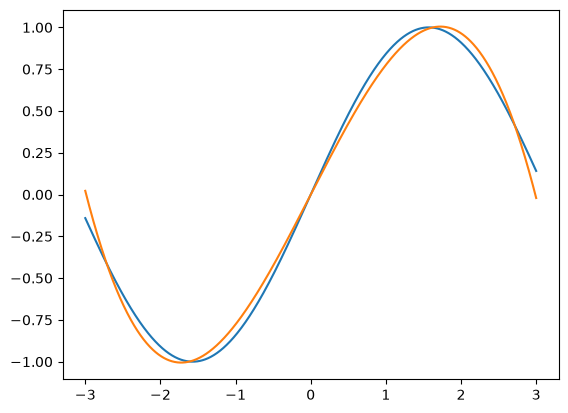

In [28]:
y_pred = model(x)
plt.plot(x,  y)
plt.plot(x,  y_pred.detach().numpy() )

In [32]:
# for i in model.parameters():
#     print(i)
list(model.parameters())

[Parameter containing:
 tensor([-0.0979], requires_grad=True),
 Parameter containing:
 tensor([0.0002], requires_grad=True),
 Parameter containing:
 tensor([0.8740], requires_grad=True),
 Parameter containing:
 tensor([-0.0008], requires_grad=True)]

- 파이토치 사용하기 2 :  최종판

In [ ]:
class Poly(nn.Module):
    def __init__(self):
        super().__init__()
        
        # 가중치 초기화
        self.a = nn.Parameter(torch.randn(1))
        self.b = nn.Parameter(torch.randn(1))
        self.c = nn.Parameter(torch.randn(1))
        self.d = nn.Parameter(torch.randn(1))

    def forward(self, x):
        y_pred  = self.a*x**3 + self.b*x**2 + self.c*x + self.d
        return y_pred            

In [33]:
# 하이퍼 파라미터 
learning_rate = 1e-6

# 데이터셋
x = torch.linspace(-3, 3, 1000)
y = torch.sin(x)

# 모델초기화
model = Poly()

# 옵티마이저 만들기
optimizer = torch.optim.SGD(params= model.parameters(), lr=learning_rate ) 

for epoch in range(6001):         
    optimizer.zero_grad()                      # 각 변수의 기울기 초기화    
    y_pred = model(x)                         # 순전파    
    criterion = nn.MSELoss(reduction='sum')   # 손실함수 정의   
    loss = criterion(y_pred, y)              # 손실 계산    
    loss.backward()                          # backward  : 미분해서 기울기 다 찾아두기     
    optimizer.step()                         # 가중치 a,b,c,d 업데이트   
   
    if epoch % 1000 == 0:
        print(f"epoch: {epoch},  loss: {loss}")
        print(f"a: {a.item()},  b: {b.item()}")
        print(f"=="*10)      

epoch: 0,  loss: 73677.625
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 1000,  loss: 214.4148712158203
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 2000,  loss: 36.695335388183594
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 3000,  loss: 8.393864631652832
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 4000,  loss: 3.863558530807495
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 5000,  loss: 3.134336471557617
a: -0.09833996742963791,  b: 0.0012902951566502452
epoch: 6000,  loss: 3.016270399093628
a: -0.09833996742963791,  b: 0.0012902951566502452


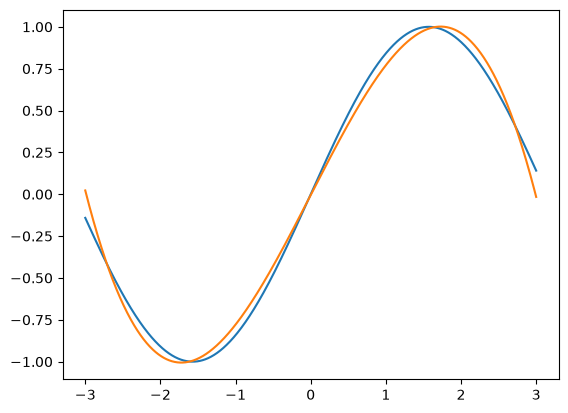

In [34]:
y_pred = model(x)
plt.plot(x,  y)
plt.plot(x,  y_pred.detach().numpy() )